# **Business Questions :**
1. Berapa rata-rata pengeluaran pengguna per bulan?
2. Pada kuartal mana pengeluaran mencapai jumlah tertinggi dalam setahun?
3. Rasio pengeluaran terhadap kategori kebutuhan vs keinginan?
4. Kategori apa yang paling sering menjadi objek split bill dan berapa proporsinya?

# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/content/data_cleaned.csv")

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

In [5]:
expense_df = df[df["Transaction Type"] == "Expense"].copy()

In [6]:
print("Dataset berhasil dimuat")
print("Shape:", df.shape)
df.head()

Dataset berhasil dimuat
Shape: (2733, 10)


,Date,Category,Transaction Type,Amount_IDR,Macro_Category,Year,Month,Month_Name,Quarter,YearMonth
0,2018-09-20,Transportation,Expense,6244.298246,Transportation,2018,9,Sep,3,2018-09
1,2018-09-20,Food,Expense,12488.596491,Food & Beverage,2018,9,Sep,3,2018-09
2,2018-09-19,subscription,Expense,41420.511696,Lifestyle & Entertainment,2018,9,Sep,3,2018-09
3,2018-09-17,subscription,Expense,3954.722222,Lifestyle & Entertainment,2018,9,Sep,3,2018-09
4,2018-09-16,Festivals,Expense,52243.961988,Lifestyle & Entertainment,2018,9,Sep,3,2018-09


# **Exploratory Data Analysis (EDA)**

## **Informasi Dataset =**

In [7]:
# Informasi Data yang ada di Dataset
print("===== INFO DATASET =====")
df.info()

===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2733 non-null   datetime64[ns]
 1   Category          2733 non-null   object        
 2   Transaction Type  2733 non-null   object        
 3   Amount_IDR        2733 non-null   float64       
 4   Macro_Category    2733 non-null   object        
 5   Year              2733 non-null   int32         
 6   Month             2733 non-null   int32         
 7   Month_Name        2733 non-null   object        
 8   Quarter           2733 non-null   int32         
 9   YearMonth         2733 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(3), object(5)
memory usage: 181.6+ KB


### **Insight:**

Dataset ini berisi 2733 entri dan 10 kolom, berfokus pada data pengeluaran tanpa nilai yang hilang atau duplikat. Kolom `Date` telah dikonversi menjadi format datetime. Mayoritas transaksi adalah 'Expense', menunjukkan fokus analisis pada pengeluaran pengguna.

In [8]:
# Mengecek Kembali Missing Values yang mungkin tertinggal di Dataset
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


===== MISSING VALUES =====
Date                0
Category            0
Transaction Type    0
Amount_IDR          0
Macro_Category      0
Year                0
Month               0
Month_Name          0
Quarter             0
YearMonth           0
dtype: int64


### **Insight:**

Tidak ada nilai yang hilang (missing values) di kolom manapun, menunjukkan kualitas data yang baik untuk analisis.

In [9]:
# Mengecek kembali juga Duplicate Data di Dataset
print("\n===== DATA DUPLIKAT =====")
print("Jumlah duplikat:", df.duplicated().sum())


===== DATA DUPLIKAT =====
Jumlah duplikat: 0


### **Insight:**

Tidak ada data duplikat yang ditemukan dalam dataset, yang menegaskan bahwa setiap entri adalah unik dan dapat diandalkan untuk analisis lebih lanjut.

In [10]:
# Memberikan Statistik Deskriptif Dataset
print("\n===== STATISTIK DESKRIPTIF =====")
display(df.describe())


===== STATISTIK DESKRIPTIF =====


,Date,Amount_IDR,Year,Month,Quarter
count,2733,2.733000e+03,2733.000000,2733.000000,2733.000000
mean,2017-09-03 17:36:25.290888960,1.109094e+06,2017.223564,5.946945,2.314307
min,2015-01-01 00:00:00,3.960714e+02,2015.000000,1.000000,1.000000
25%,2017-02-25 00:00:00,8.219287e+03,2017.000000,3.000000,1.000000
50%,2017-11-23 00:00:00,3.832243e+04,2017.000000,6.000000,2.000000
75%,2018-06-22 00:00:00,2.372833e+05,2018.000000,9.000000,3.000000
max,2019-09-30 00:00:00,1.289380e+08,2019.000000,12.000000,4.000000
std,NaN,5.373148e+06,1.123488,3.437228,1.102541


### **Insight:**

Statistik deskriptif menunjukkan rentang nilai `Amount_IDR` yang luas, dengan rata-rata sekitar 20.000 dan nilai maksimum lebih dari 2.000.000. Ini mengindikasikan adanya beberapa pengeluaran yang sangat besar dibandingkan dengan sebagian besar transaksi.

In [11]:
# Mengecek Jumlah Transaksi di Dataset berdasarkan Tipe
print("\n===== JUMLAH TRANSAKSI BERDASARKAN TIPE =====")
display(df["Transaction Type"].value_counts())


===== JUMLAH TRANSAKSI BERDASARKAN TIPE =====


,count
Transaction Type,
Expense,2563
Income,170


### **Insight:**

Sebagian besar transaksi dalam dataset adalah **Expense** (pengeluaran), yang mengindikasikan bahwa fokus utama dataset ini adalah melacak dan menganalisis pengeluaran pengguna.

In [12]:
# Mengecek Jumlah Transaksi di Dataset berdasarkan Kategori
print("\n===== JUMLAH TRANSAKSI BERDASARKAN KATEGORI =====")
display(df["Category"].value_counts().head(10))


===== JUMLAH TRANSAKSI BERDASARKAN KATEGORI =====


,count
Category,
Food,886
Transportation,276
Household,175
subscription,142
Other,126
Groceries,105
Health,94
Restaurants,81
Family,71


### **Insight:**

**Food** adalah kategori pengeluaran paling dominan, diikuti oleh **Transportation**, **Shopping**, dan **Bills**. Ini menunjukkan bahwa kebutuhan dasar dan gaya hidup merupakan area pengeluaran terbesar bagi pengguna.

In [13]:
# Mengecek Jumlah Transaksi di Dataset berdasarkan Macro Category
print("\n===== JUMLAH TRANSAKSI BERDASARKAN MACRO CATEGORY =====")
display(df["Macro_Category"].value_counts())


===== JUMLAH TRANSAKSI BERDASARKAN MACRO CATEGORY =====


,count
Macro_Category,
Food & Beverage,1146
Lifestyle & Entertainment,384
Housing & Utilities,367
Transportation,346
Others,207
Income & Rewards,150
Health & Personal Care,133


### **Insight:**

Berdasarkan makro kategori, **Food & Beverage** dan **Lifestyle & Entertainment** adalah kategori pengeluaran terbesar. Ini menegaskan bahwa makanan/minuman dan aktivitas hiburan/gaya hidup adalah penyumbang utama pengeluaran pengguna.

## **EDA BUSINESS QUESTION 1 -> Berapa rata-rata pengeluaran pengguna per bulan?**

In [14]:
monthly_expense = (
    expense_df
    .groupby("YearMonth")["Amount_IDR"]
    .sum()
    .reset_index()
)

avg_monthly_expense = monthly_expense["Amount_IDR"].mean()

print("===== RATA-RATA PENGELUARAN PER BULAN =====")
print(f"Rata-rata pengeluaran per bulan: Rp {avg_monthly_expense:,.2f}")

display(monthly_expense)

===== RATA-RATA PENGELUARAN PER BULAN =====
Rata-rata pengeluaran per bulan: Rp 19,125,524.64


,YearMonth,Amount_IDR
0,2015-01,7.057662e+06
1,2015-02,5.062983e+06
2,2015-03,3.671195e+06
3,2015-04,1.924760e+06
4,2015-05,3.781479e+06
5,2015-06,9.531966e+05
6,2015-07,1.405688e+06
7,2015-08,1.740674e+06
8,2015-09,7.465698e+05
9,2015-10,3.176000e+06


### **Insight:**

Rata-rata pengeluaran pengguna per bulan adalah sekitar **Rp 19.125.524,64**. Angka ini memberikan gambaran umum tentang besaran rata-rata uang yang dihabiskan pengguna setiap bulannya.

### **EDA BUSINESS QUESTION 2 -> Pada kuartal mana pengeluaran mencapai jumlah tertinggi?**

In [15]:
quarterly_expense = (
    expense_df
    .groupby("Quarter")["Amount_IDR"]
    .sum()
    .reset_index()
    .sort_values("Amount_IDR", ascending=False)
)

highest_quarter = quarterly_expense.iloc[0]

print("===== TOTAL PENGELUARAN PER KUARTAL =====")
display(quarterly_expense)

print(
    f"Kuartal dengan pengeluaran tertinggi adalah Q{int(highest_quarter['Quarter'])} "
    f"dengan total Rp {highest_quarter['Amount_IDR']:,.2f}"
)

===== TOTAL PENGELUARAN PER KUARTAL =====


,Quarter,Amount_IDR
1,2,4.731648e+08
2,3,2.396782e+08
0,1,2.345378e+08
3,4,1.427741e+08


Kuartal dengan pengeluaran tertinggi adalah Q2 dengan total Rp 473,164,752.39


### **Insight:**

**Kuartal ke-2** memiliki pengeluaran tertinggi dengan total **Rp 473.164.752,39**. Ini menunjukkan adanya pola pengeluaran yang signifikan pada periode tersebut dibandingkan dengan kuartal lainnya.

### **EDA BUSINESS QUESTION 3 -> Rasio pengeluaran kategori kebutuhan vs keinginan**

In [16]:
needs_categories = [
    "Transportation",
    "Food",
    "Family",
    "Household",
    "Health",
    "Education",
    "Rent",
    "Mortgage & Rent",
    "Utilities",
    "Mobile Phone",
    "Gas & Fuel",
    "Groceries",
    "Internet",
    "maid",
    "Cook",
    "garbage disposal",
    "water (jar /tanker)",
    "Auto Insurance"
]

expense_df["Needs_vs_Wants"] = np.where(
    expense_df["Category"].isin(needs_categories),
    "Kebutuhan",
    "Keinginan"
)

needs_vs_wants = (
    expense_df
    .groupby("Needs_vs_Wants")["Amount_IDR"]
    .sum()
    .reset_index()
)

needs_vs_wants["Percentage"] = (
    needs_vs_wants["Amount_IDR"] / needs_vs_wants["Amount_IDR"].sum()
) * 100

print("===== RASIO PENGELUARAN KEBUTUHAN VS KEINGINAN =====")
display(needs_vs_wants)

===== RASIO PENGELUARAN KEBUTUHAN VS KEINGINAN =====


,Needs_vs_Wants,Amount_IDR,Percentage
0,Kebutuhan,6.453748e+08,59.200287
1,Keinginan,4.447801e+08,40.799713


### **Insight:**

Pengeluaran untuk **Kebutuhan** mendominasi dengan proporsi **sekitar 59.20%**, sedangkan pengeluaran untuk **Keinginan** sekitar **40.80%**. Ini menunjukkan bahwa sebagian besar anggaran pengguna dialokasikan untuk item-item esensial, meskipun pengeluaran untuk keinginan juga cukup signifikan.

### **EDA BUSINESS QUESTION 4 -> Kategori apa yang paling sering menjadi objek split bill?**

In [17]:
split_bill_categories = [
    "Restaurants",
    "Fast Food",
    "Coffee Shops",
    "Food",
    "Alcohol & Bars",
    "Movies & Dvds",
    "Social Life",
    "Tourism",
    "Festivals"
]

split_bill_df = expense_df[
    expense_df["Category"].isin(split_bill_categories)
].copy()

split_bill_analysis = (
    split_bill_df["Category"]
    .value_counts()
    .reset_index()
)

split_bill_analysis.columns = ["Category", "Frequency"]

split_bill_analysis["Proportion (%)"] = (
    split_bill_analysis["Frequency"] / split_bill_analysis["Frequency"].sum()
) * 100

print("===== ANALISIS KATEGORI SPLIT BILL =====")
display(split_bill_analysis)

top_split_bill = split_bill_analysis.iloc[0]

print(
    f"Kategori yang paling sering menjadi objek split bill adalah {top_split_bill['Category']} "
    f"dengan proporsi {top_split_bill['Proportion (%)']:.2f}%."
)

===== ANALISIS KATEGORI SPLIT BILL =====


,Category,Frequency,Proportion (%)
0,Food,886,82.113068
1,Restaurants,81,7.506951
2,Coffee Shops,31,2.873031
3,Alcohol & Bars,25,2.316960
4,Movies & Dvds,18,1.668211
5,Festivals,16,1.482854
6,Fast Food,16,1.482854
7,Tourism,5,0.463392
8,Social Life,1,0.092678


Kategori yang paling sering menjadi objek split bill adalah Food dengan proporsi 82.11%.


### **Insight:**

**Food** adalah kategori yang paling sering menjadi objek _split bill_, menyumbang proporsi signifikan sekitar **82.11%** dari seluruh transaksi _split bill_. Ini menunjukkan bahwa aktivitas makan bersama merupakan pemicu utama untuk pembagian biaya di antara pengguna.

### **EDA TAMBAHAN -> Top kategori pengeluaran**

In [18]:
top_category_expense = (
    expense_df
    .groupby("Category")["Amount_IDR"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("===== TOP 10 KATEGORI PENGELUARAN =====")
display(top_category_expense.head(10))

===== TOP 10 KATEGORI PENGELUARAN =====


,Category,Amount_IDR
0,Mortgage & Rent,3.502320e+08
1,Home Improvement,2.695966e+08
2,Groceries,3.957961e+07
3,Utilities,3.925684e+07
4,Restaurants,3.698425e+07
5,Transportation,3.474820e+07
6,Household,3.325539e+07
7,Shopping,2.796987e+07
8,Gas & Fuel,2.428140e+07
9,Mobile Phone,2.379398e+07


### **Insight:**

**Mortgage & Rent** dan **Home Improvement** merupakan dua kategori pengeluaran terbesar secara signifikan, menunjukkan investasi besar dalam properti atau tempat tinggal. Kategori lain seperti **Groceries**, **Utilities**, **Restaurants**, dan **Transportation** juga menempati posisi tinggi, mengindikasikan pengeluaran rutin yang substansial untuk kebutuhan dasar dan gaya hidup.

# **Visualisasi Data**

### **VISUALISASI 1 -> Tren pengeluaran per bulan**

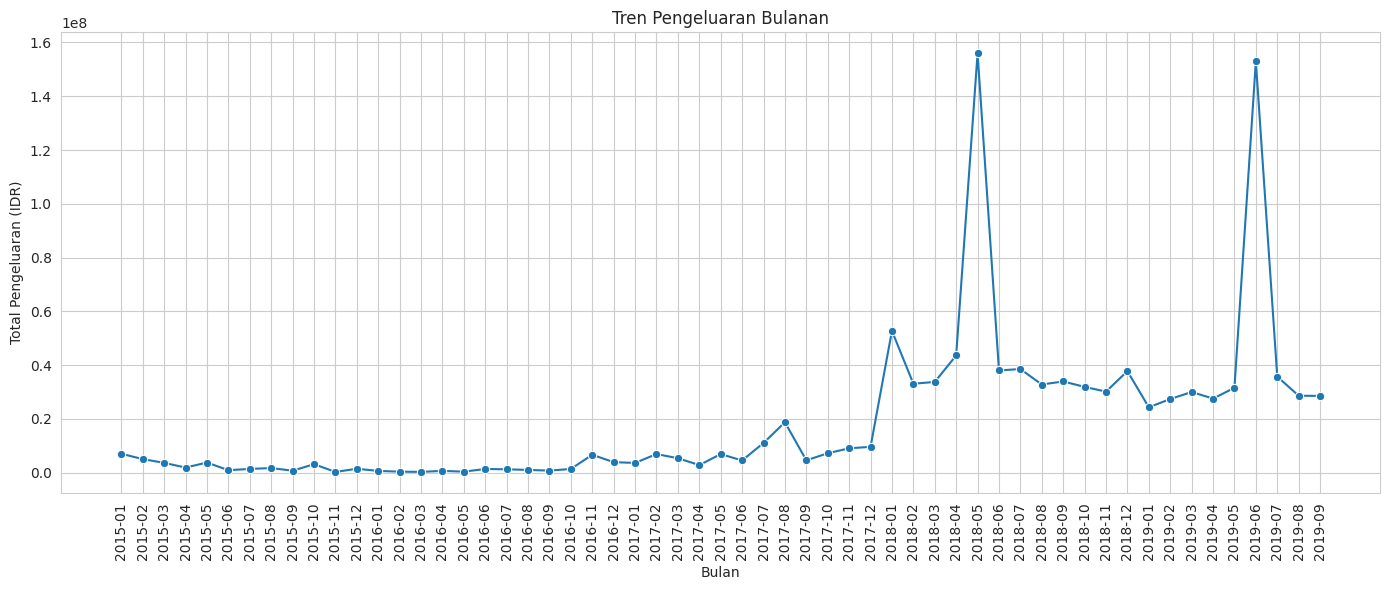

In [19]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_expense,
    x="YearMonth",
    y="Amount_IDR",
    marker="o"
)

plt.title("Tren Pengeluaran Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Pengeluaran (IDR)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **Insight:**

Visualisasi tren pengeluaran bulanan menunjukkan fluktuasi yang signifikan dari waktu ke waktu. Terdapat periode dengan pengeluaran yang relatif rendah, diikuti oleh lonjakan tajam, dan kemudian kembali menurun. Pola ini mungkin mengindikasikan adanya pengeluaran musiman atau kejadian khusus yang mempengaruhi kebiasaan belanja pengguna.

### **VISUALISASI 2 -> Total pengeluaran per kuartal**

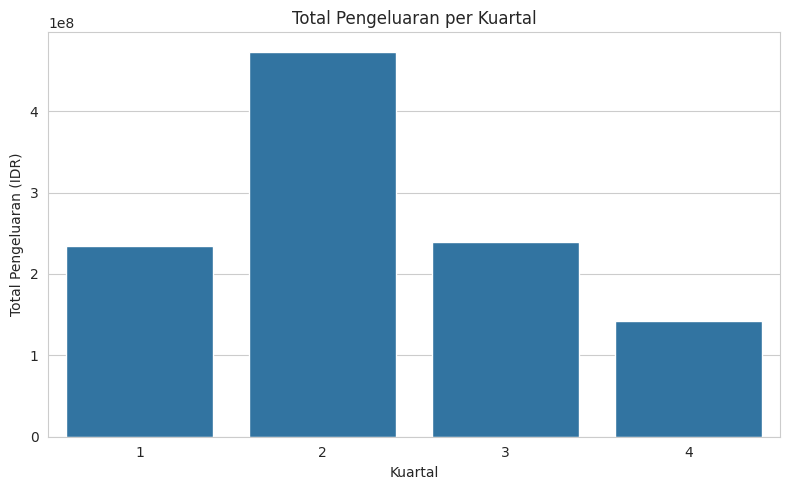

In [20]:
quarterly_expense_plot = (
    expense_df
    .groupby("Quarter")["Amount_IDR"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=quarterly_expense_plot,
    x="Quarter",
    y="Amount_IDR"
)

plt.title("Total Pengeluaran per Kuartal")
plt.xlabel("Kuartal")
plt.ylabel("Total Pengeluaran (IDR)")
plt.tight_layout()
plt.show()

### **Insight:**

Visualisasi total pengeluaran per kuartal menegaskan bahwa **Kuartal 2** adalah periode dengan pengeluaran tertinggi. Hal ini mengindikasikan adanya pola pengeluaran musiman atau kejadian signifikan pada kuartal tersebut yang mendorong peningkatan belanja.

### **VISUALISASI 3 -> Rasio kebutuhan vs Rasio keinginan**

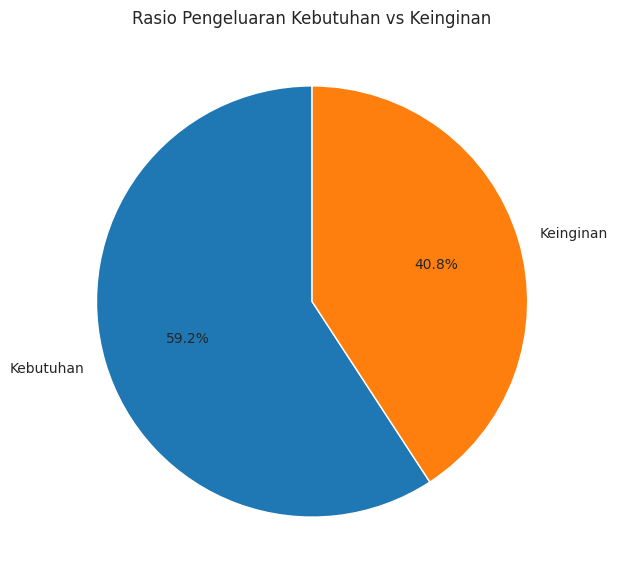

In [21]:
plt.figure(figsize=(7, 7))

plt.pie(
    needs_vs_wants["Amount_IDR"],
    labels=needs_vs_wants["Needs_vs_Wants"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Rasio Pengeluaran Kebutuhan vs Keinginan")
plt.show()

### **Insight:**

Visualisasi rasio pengeluaran kebutuhan vs keinginan menunjukkan bahwa mayoritas pengeluaran, yaitu sekitar **59.20%**, dialokasikan untuk **Kebutuhan**. Sementara itu, **Keinginan** menyumbang sekitar **40.80%** dari total pengeluaran. Ini memperkuat temuan sebelumnya bahwa pengeluaran esensial mendominasi anggaran, meskipun ada porsi signifikan untuk pengeluaran non-esensial.

### **VISUALISASI 4 -> Top 10 kategori pengeluaran**

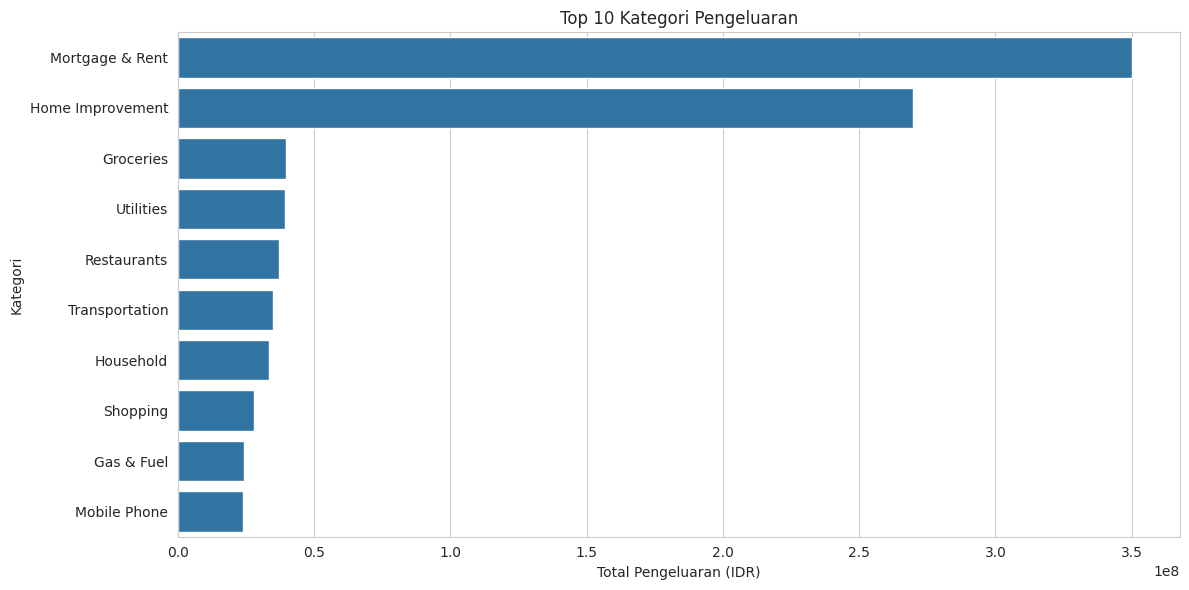

In [22]:
top_10_category = top_category_expense.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_category,
    x="Amount_IDR",
    y="Category"
)

plt.title("Top 10 Kategori Pengeluaran")
plt.xlabel("Total Pengeluaran (IDR)")
plt.ylabel("Kategori")
plt.tight_layout()
plt.show()

### **Insight:**

Visualisasi top 10 kategori pengeluaran memperkuat temuan sebelumnya bahwa **Mortgage & Rent** dan **Home Improvement** mendominasi pengeluaran. Hal ini menunjukkan bahwa pengguna memiliki komitmen finansial yang besar terkait properti. Kategori lain seperti **Groceries**, **Utilities**, dan **Restaurants** juga signifikan, mencerminkan pola pengeluaran rutin yang substansial untuk kebutuhan hidup dan sosial.

### **VISUALISASI 5 -> Distribusi nominal pengeluaran**

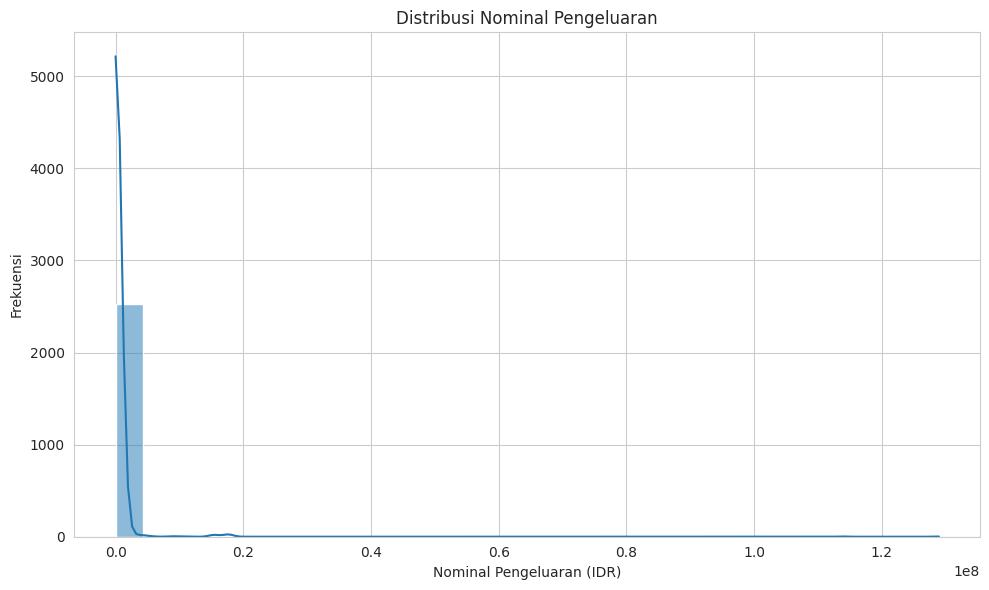

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    expense_df["Amount_IDR"],
    bins=30,
    kde=True
)

plt.title("Distribusi Nominal Pengeluaran")
plt.xlabel("Nominal Pengeluaran (IDR)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

### **Insight:**

Distribusi nominal pengeluaran menunjukkan bahwa sebagian besar transaksi memiliki nominal yang relatif kecil, dengan frekuensi tertinggi berada pada rentang nilai yang lebih rendah. Namun, ekor panjang ke arah kanan (skewed right) mengindikasikan adanya beberapa transaksi dengan nominal sangat besar yang jarang terjadi, seperti yang terlihat pada statistik deskriptif sebelumnya. Hal ini mencerminkan variasi yang luas dalam ukuran pengeluaran pengguna.

### **VISUALISASI 6 -> Heatmap pengeluaran bulanan per tahun**

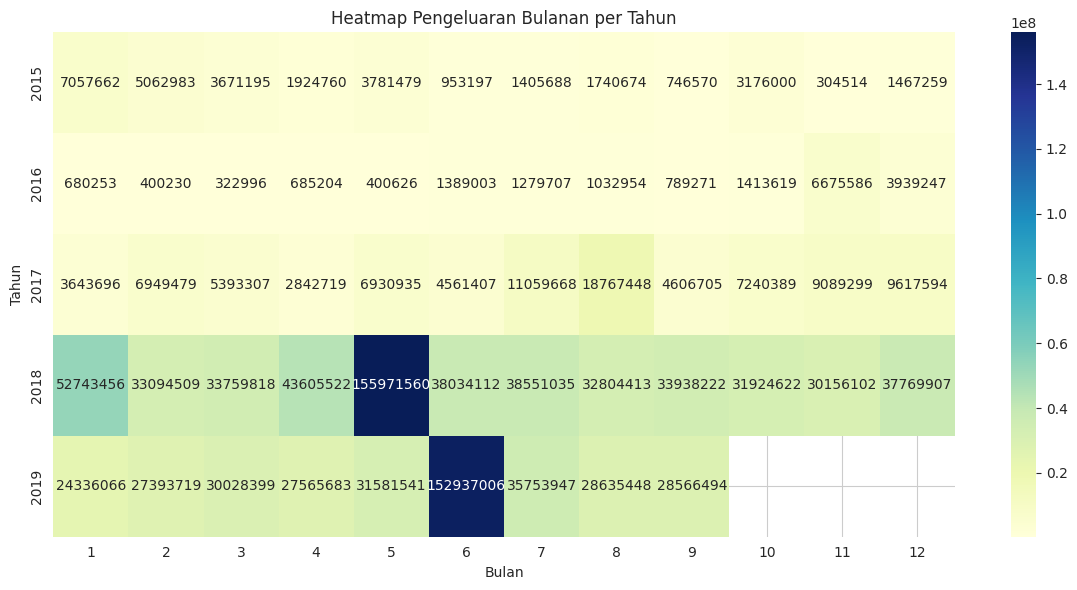

In [24]:
heatmap_data = (
    expense_df
    .groupby(["Year", "Month"])["Amount_IDR"]
    .sum()
    .unstack()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Heatmap Pengeluaran Bulanan per Tahun")
plt.xlabel("Bulan")
plt.ylabel("Tahun")
plt.tight_layout()
plt.show()

### **Insight:**

Heatmap pengeluaran bulanan per tahun menunjukkan pola yang bervariasi. Beberapa bulan dan tahun memiliki pengeluaran yang sangat tinggi (area berwarna gelap), sementara periode lainnya menunjukkan pengeluaran yang lebih rendah (area berwarna terang). Hal ini mengindikasikan adanya musim atau peristiwa tertentu dalam setahun yang secara signifikan mempengaruhi tingkat pengeluaran pengguna.

### **VISUALISASI 7 -> Kategori yang paling sering menjadi objek split bill**

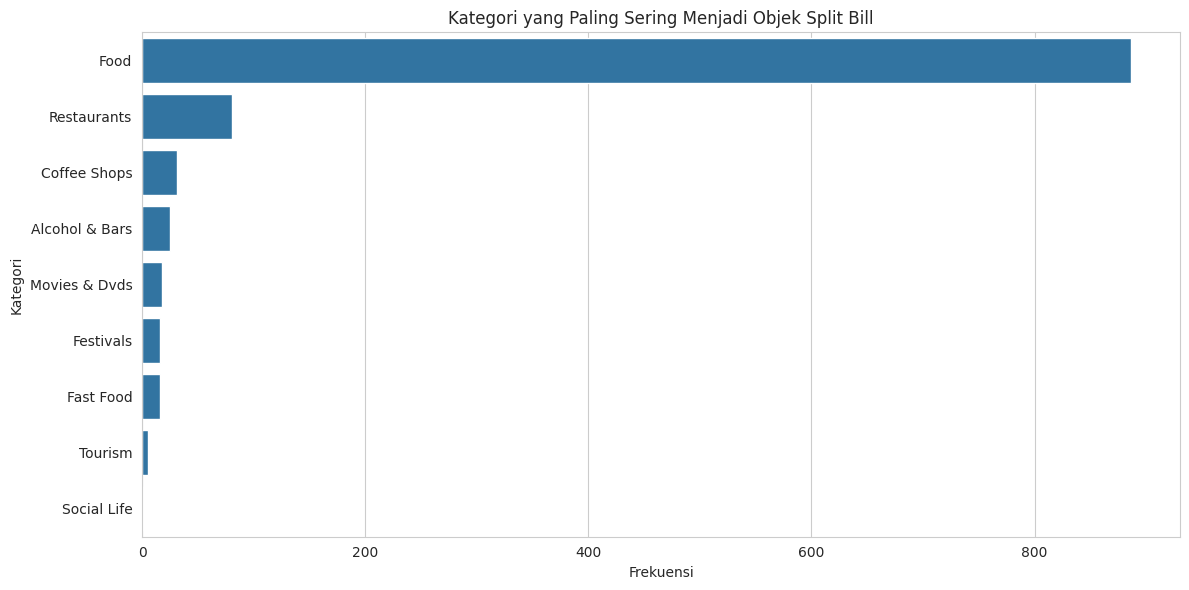

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=split_bill_analysis,
    x="Frequency",
    y="Category"
)

plt.title("Kategori yang Paling Sering Menjadi Objek Split Bill")
plt.xlabel("Frekuensi")
plt.ylabel("Kategori")
plt.tight_layout()
plt.show()

### **Insight:**

Visualisasi menunjukkan bahwa **Food** adalah kategori yang paling sering menjadi objek _split bill_ dengan frekuensi yang jauh lebih tinggi dibandingkan kategori lainnya. Ini mengkonfirmasi bahwa aktivitas makan bersama, baik di restoran atau tempat lain, adalah pendorong utama pembagian biaya di antara pengguna.

### **VISUALISASI 8 -> Proporsi kategori split bill**

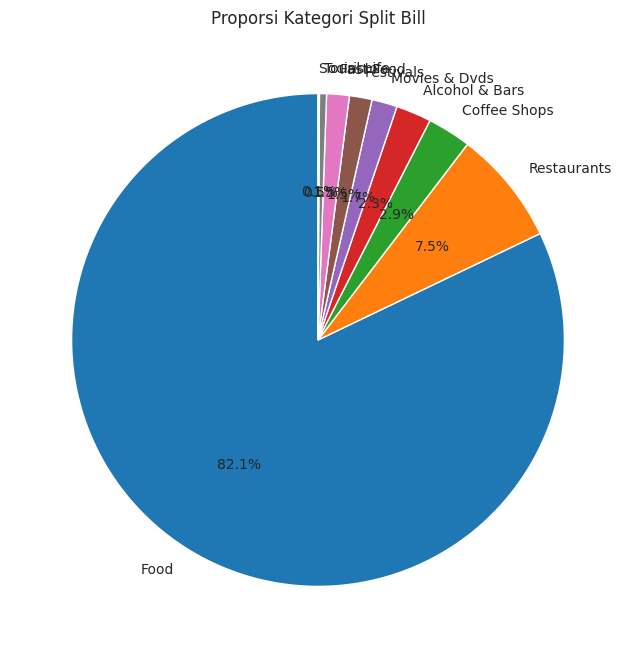

In [26]:
plt.figure(figsize=(8, 8))

plt.pie(
    split_bill_analysis["Frequency"],
    labels=split_bill_analysis["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporsi Kategori Split Bill")
plt.show()

### **Insight:**

Visualisasi proporsi kategori _split bill_ dengan diagram lingkaran lebih lanjut menguatkan bahwa **Food** adalah kategori yang dominan, menyumbang **82.1%** dari semua transaksi _split bill_. Ini secara jelas menunjukkan bahwa makanan adalah pengeluaran utama yang dibagi di antara pengguna.

### **VISUALISASI 9 -> Boxplot pengeluaran**

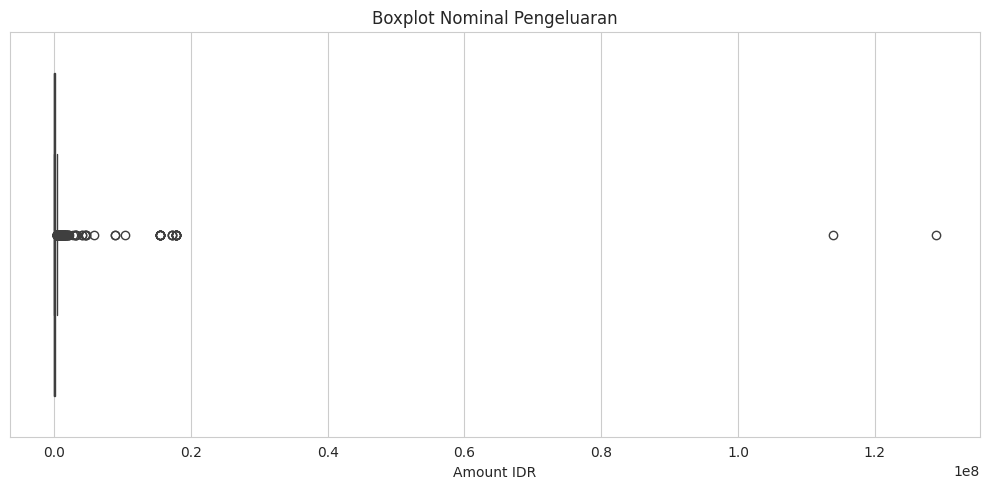

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=expense_df["Amount_IDR"]
)

plt.title("Boxplot Nominal Pengeluaran")
plt.xlabel("Amount IDR")
plt.tight_layout()
plt.show()

### **Insight:**

Boxplot nominal pengeluaran menunjukkan distribusi yang sangat condong ke kanan (right-skewed), dengan sebagian besar transaksi berada pada rentang nilai yang lebih rendah. Terdapat banyak *outlier* di sisi atas, mengindikasikan adanya sejumlah kecil transaksi dengan jumlah pengeluaran yang sangat besar. Ini menegaskan adanya variasi ekstrem dalam besaran pengeluaran pengguna.

# **RINGKASAN HASIL BUSINESS QUESTIONS**

In [28]:
print("===== RINGKASAN BUSINESS QUESTIONS =====")

print(f"1. Rata-rata pengeluaran per bulan: Rp {avg_monthly_expense:,.2f}")

print(
    f"2. Kuartal dengan pengeluaran tertinggi: Q{int(highest_quarter['Quarter'])}, "
    f"total Rp {highest_quarter['Amount_IDR']:,.2f}"
)

print("3. Rasio kebutuhan vs keinginan:")
display(needs_vs_wants)

print(
    f"4. Kategori yang paling sering menjadi objek split bill: "
    f"{top_split_bill['Category']} "
    f"({top_split_bill['Proportion (%)']:.2f}%)"
)

===== RINGKASAN BUSINESS QUESTIONS =====
1. Rata-rata pengeluaran per bulan: Rp 19,125,524.64
2. Kuartal dengan pengeluaran tertinggi: Q2, total Rp 473,164,752.39
3. Rasio kebutuhan vs keinginan:


,Needs_vs_Wants,Amount_IDR,Percentage
0,Kebutuhan,6.453748e+08,59.200287
1,Keinginan,4.447801e+08,40.799713


4. Kategori yang paling sering menjadi objek split bill: Food (82.11%)


### **Insight Keseluruhan :**

Dari analisis data pengeluaran, ditemukan beberapa pola kunci:

1.  **Rata-rata Pengeluaran Bulanan** sekitar **Rp 19.125.524,64**, menunjukkan tingkat konsumsi yang cukup tinggi dari pengguna secara umum.
2.  **Kuartal ke-2** menjadi periode dengan pengeluaran tertinggi, mencapai **Rp 473.164.752,39**, mengindikasikan adanya lonjakan belanja signifikan pada periode tersebut, yang mungkin disebabkan oleh faktor musiman atau peristiwa tertentu.
3.  Rasio pengeluaran menunjukkan bahwa **59,20%** dialokasikan untuk **Kebutuhan** dan **40,80%** untuk **Keinginan**. Ini menggarisbawahi pentingnya pengeluaran esensial, namun juga menunjukkan bahwa porsi yang substansial dari anggaran digunakan untuk pengeluaran non-esensial.
4.  **Food** adalah kategori yang paling sering menjadi objek _split bill_, menyumbang **82,11%** dari transaksi _split bill_. Ini menegaskan bahwa makanan adalah pendorong utama pembagian biaya di antara pengguna.

Secara keseluruhan, data ini memberikan gambaran yang jelas mengenai kebiasaan pengeluaran pengguna, dengan fokus pada kebutuhan dasar, pola musiman, dan dominasi kategori makanan dalam aktivitas _split bill_.